# 02 Process Economic Variables at FOMC Meetings

## Purpose

This notebook starts from the meeting-level fed funds rate dataset exported in Part 1 and
aligns the core macro variables used in the analysis at FOMC meeting frequency.

## Pipeline Position

This is the main feature-construction notebook. It consumes `processed_fed_meetings.csv`
from Part 1 and exports `df_model.csv` / `df_model.parquet`, which are the modeling
tables used in notebooks 03, 03.2, and 04.

## Economic Motivation

The selected variables are tied to the Federal Reserve's stated monetary policy goals. The
[Federal Reserve FAQ on monetary policy goals](https://www.federalreserve.gov/faqs/what-economic-goals-does-federal-reserve-seek-to-achieve-through-monetary-policy.htm)
explains that Congress assigns the Fed to conduct monetary policy in support of maximum
employment and stable prices, commonly described as the dual mandate. It also notes that
the FOMC judges 2 percent inflation, measured by the annual change in the PCE price index,
to be most consistent with the price-stability mandate over the longer run.

For that reason, this notebook builds meeting-level features that proxy the economic
conditions FOMC participants monitor when setting the federal funds rate: PCE inflation and
the PCE inflation gap for price stability, unemployment and the unemployment gap for labor
market slack, the output gap for real activity relative to potential, and the Chicago Fed
NFCI for broader financial conditions. These variables give the forecasting models a
structured representation of the macroeconomic information that is relevant to FOMC policy
decisions.

## Notation

| Symbol | Meaning |
|---|---|
| `r_t` | Upper bound target federal funds rate after meeting `t` |
| `r_{t-1}` | Lagged upper bound target federal funds rate from the previous meeting |
| `π_t` | Year-over-year PCE inflation observed before meeting `t` |
| `π_t - 2` | PCE inflation gap relative to the Fed's 2% target |
| `u_t - u_t^*` | Unemployment gap: UNRATE minus NROU |
| `y_t - y_t^*` | Output gap: real GDP relative to potential GDP |
| `NFCI_t` | Chicago Fed NFCI |

## Input

At the start of the notebook, the local data files are refreshed from their source URLs when internet is available. Each refresh overwrites the local CSV with the newest complete source copy, so repeated runs do not append duplicate rows. If a source is temporarily unavailable, the notebook falls back to the local copy.

The meeting-level dataset is `processed_fed_meetings.csv`, originally exported by Part 1 and refreshed here before feature construction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.notebook_io import data_output_path, resolve_data_source
from modeling.data_refresh import refresh_economic_sources, refresh_processed_fed_meetings

def minmax_normalize(series):
    """Expanding-window min-max scale a Series to [0, 1] without look-ahead."""
    series = series.astype(float)
    lo = series.expanding(min_periods=1).min()
    hi = series.expanding(min_periods=1).max()
    span = hi - lo
    scaled = pd.Series(np.where(span.eq(0), 0.0, (series - lo) / span),
                       index=series.index, dtype=float)
    return scaled.where(series.notna(), np.nan)

def locf_match(df_src, date_col, val_cols, dates):
    dates_df = pd.DataFrame({'meeting_date': pd.Series(dates).values})
    src = df_src[[date_col] + list(val_cols)].sort_values(date_col)
    result = pd.merge_asof(
        dates_df.sort_values('meeting_date'),
        src,
        left_on='meeting_date',
        right_on=date_col,
        direction='backward',
    )
    if date_col != 'meeting_date':
        result = result.drop(columns=[date_col])
    return result.reset_index(drop=True)


In [2]:
print('Refreshing Part 1 FOMC meeting/rate data...')
fomc_refresh_result = refresh_processed_fed_meetings(PROJECT_ROOT)
print(fomc_refresh_result.message())

print('\nRefreshing Part 2 economic source data...')
for refresh_result in refresh_economic_sources(PROJECT_ROOT):
    print(refresh_result.message())

meetings_path = resolve_data_source('processed_fed_meetings.csv', PROJECT_ROOT)
df_merged = pd.read_csv(meetings_path, parse_dates=['meeting_date'])
df_merged_all = df_merged.copy()

print(f"Loaded {len(df_merged)} meeting rows from {meetings_path}")
display(df_merged.tail())


Refreshing Part 1 FOMC meeting/rate data...


processed_fed_meetings.csv: wrote 141 rows (2009-01-28 -> 2026-03-18)

Refreshing Part 2 economic source data...


PCEPI Personal Consumption Expenditures.csv: wrote 806 rows (1959-01-01 -> 2026-02-01)
Unemployment Rate UNRATE all.csv: wrote 939 rows (1948-01-01 -> 2026-03-01)
Noncyclical Rate of Unemployment.csv: wrote 352 rows (1949-01-01 -> 2036-10-01)
Real GDP Data.csv: wrote 316 rows (1947-01-01 -> 2025-10-01)
Real Potential GDP.csv: wrote 352 rows (1949-01-01 -> 2036-10-01)
Chicago Fed NFCI.csv: wrote 2884 rows (1971-01-08 -> 2026-04-10)
Loaded 141 meeting rows from /Users/echohuang/Documents/forecasting_fed_rate/data/processed_fed_meetings.csv


,meeting_date,target_rate,decision,target_rate_normalized
136,2025-09-17,4.25,lower,0.761905
137,2025-10-29,4.00,lower,0.714286
138,2025-12-10,3.75,lower,0.666667
139,2026-01-28,3.75,same,0.666667
140,2026-03-18,3.75,same,0.666667


### Incorporating PCE Inflation Data

We load the Personal Consumption Expenditures Price Index (PCEPI), compute the Year-over-Year (YoY) percentage change, and derive the **inflation gap** relative to the Fed's 2% target:

$$\pi_t^{PCE} = 100 \times \left(\frac{PCE_t}{PCE_{t-12}} - 1\right)$$

$$\text{Inflation Gap}_t = \pi_t^{PCE} - 2$$

Source: https://fred.stlouisfed.org/series/PCEPI

PCE data: 1960-01-01 → 2026-02-01

Sample rows:


,observation_date,PCEPI,PCE_YoY_pct,PCE_inflation_gap
784,2025-05-01,126.380,2.458086,0.458086
785,2025-06-01,126.743,2.593513,0.593513
786,2025-07-01,126.960,2.605547,0.605547
787,2025-08-01,127.293,2.747621,0.747621
788,2025-09-01,127.625,2.787442,0.787442
789,2025-10-01,127.871,2.712581,0.712581
790,2025-11-01,128.152,2.820190,0.820190
791,2025-12-01,128.576,2.878084,0.878084
792,2026-01-01,128.965,2.828963,0.828963
793,2026-02-01,129.449,2.801757,0.801757


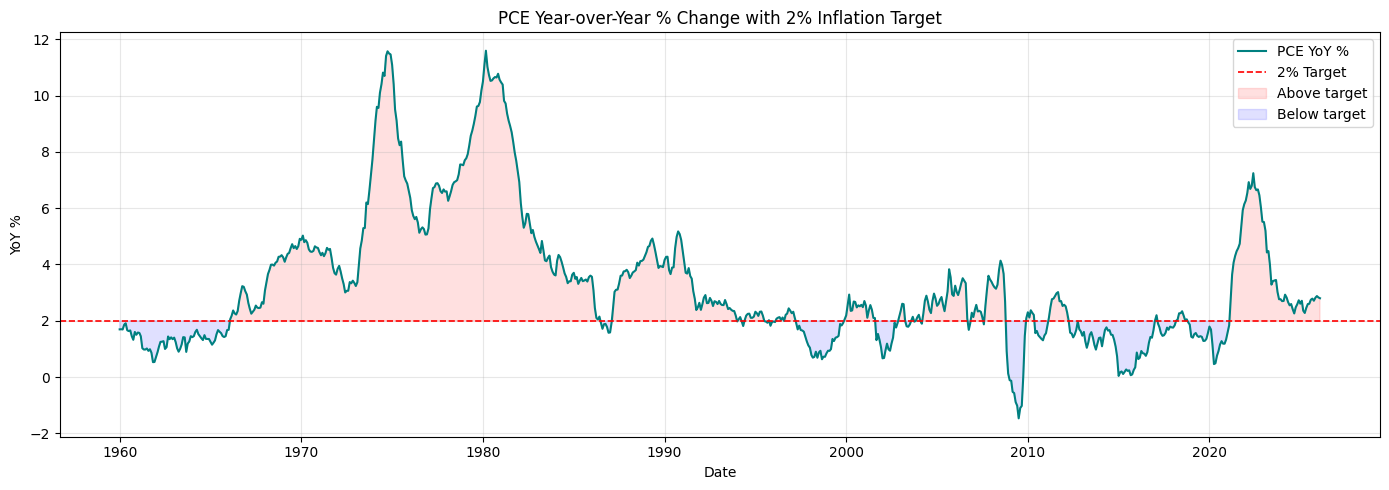

In [3]:
# 1. Load PCE data, compute YoY %, and compute inflation gap relative to 2% target
pce_path = resolve_data_source('PCEPI Personal Consumption Expenditures.csv', PROJECT_ROOT)
df_pce = pd.read_csv(pce_path)
df_pce['observation_date'] = pd.to_datetime(df_pce['observation_date'])
df_pce['PCEPI'] = pd.to_numeric(df_pce['PCEPI'], errors='coerce')
df_pce = df_pce.dropna(subset=['PCEPI']).sort_values('observation_date').reset_index(drop=True)

# PCE YoY % = 100 * (PCE_t / PCE_{t-12} - 1)
df_pce['PCE_YoY_pct'] = 100 * (df_pce['PCEPI'] / df_pce['PCEPI'].shift(12) - 1)

# Inflation gap = PCE YoY - 2% (Fed's target)
# e.g. PCE YoY = 2.8%  →  gap = +0.8
#      PCE YoY = 1.6%  →  gap = -0.4
df_pce['PCE_inflation_gap'] = df_pce['PCE_YoY_pct'] - 2.0

df_pce = df_pce.dropna(subset=['PCE_YoY_pct']).reset_index(drop=True)

print(f"PCE data: {df_pce['observation_date'].min().date()} → {df_pce['observation_date'].max().date()}")
print(f"\nSample rows:")
display(df_pce[['observation_date', 'PCEPI', 'PCE_YoY_pct', 'PCE_inflation_gap']].tail(10))

# Plot raw PCE YoY with 2% target line
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_pce['observation_date'], df_pce['PCE_YoY_pct'],
        color='teal', linewidth=1.5, label='PCE YoY %')
ax.axhline(y=2.0, color='red', linewidth=1.2, linestyle='--', label='2% Target')
ax.fill_between(df_pce['observation_date'],
                df_pce['PCE_YoY_pct'], 2.0,
                where=(df_pce['PCE_YoY_pct'] >= 2.0),
                alpha=0.12, color='red', label='Above target')
ax.fill_between(df_pce['observation_date'],
                df_pce['PCE_YoY_pct'], 2.0,
                where=(df_pce['PCE_YoY_pct'] < 2.0),
                alpha=0.12, color='blue', label='Below target')
ax.set_title('PCE Year-over-Year % Change with 2% Inflation Target')
ax.set_xlabel('Date')
ax.set_ylabel('YoY %')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

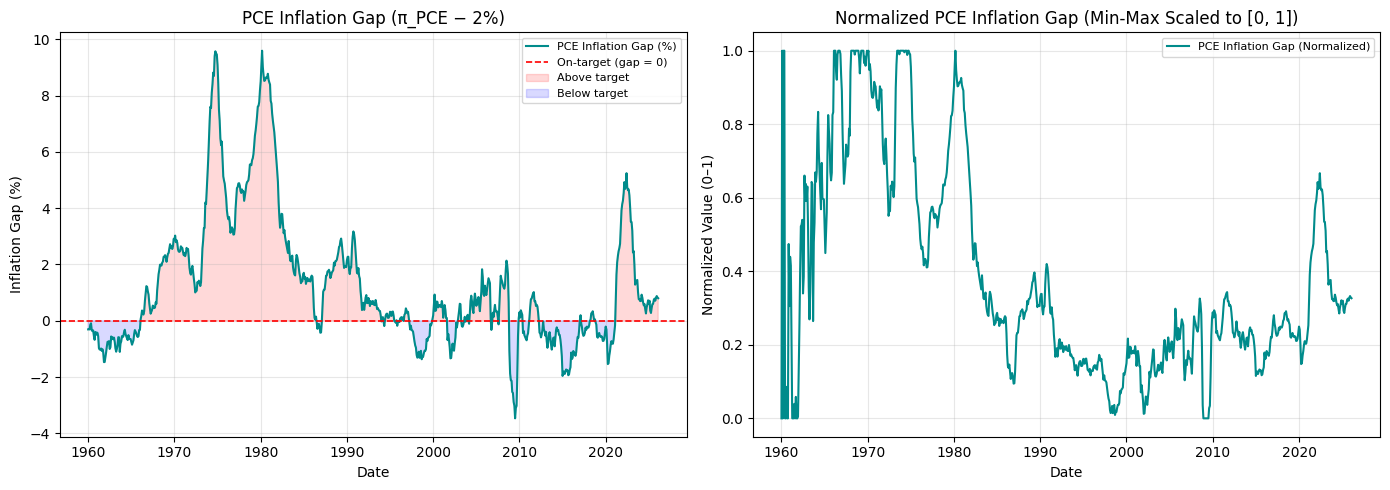

In [4]:
# 2. Normalize the inflation gap (min-max scaling, same method as fed funds rate)
df_pce['PCE_inflation_gap_normalized'] = minmax_normalize(df_pce['PCE_inflation_gap'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw inflation gap with zero-line (= on-target)
axes[0].plot(df_pce['observation_date'], df_pce['PCE_inflation_gap'],
             color='darkcyan', linewidth=1.5, label='PCE Inflation Gap (%)')
axes[0].axhline(y=0, color='red', linewidth=1.2, linestyle='--', label='On-target (gap = 0)')
axes[0].fill_between(df_pce['observation_date'], df_pce['PCE_inflation_gap'], 0,
                     where=(df_pce['PCE_inflation_gap'] > 0),
                     alpha=0.15, color='red', label='Above target')
axes[0].fill_between(df_pce['observation_date'], df_pce['PCE_inflation_gap'], 0,
                     where=(df_pce['PCE_inflation_gap'] <= 0),
                     alpha=0.15, color='blue', label='Below target')
axes[0].set_title('PCE Inflation Gap (π_PCE − 2%)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Inflation Gap (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: normalized inflation gap
axes[1].plot(df_pce['observation_date'], df_pce['PCE_inflation_gap_normalized'],
             color='darkcyan', linewidth=1.5, label='PCE Inflation Gap (Normalized)')
axes[1].set_title('Normalized PCE Inflation Gap (Min-Max Scaled to [0, 1])')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Normalized Value (0–1)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

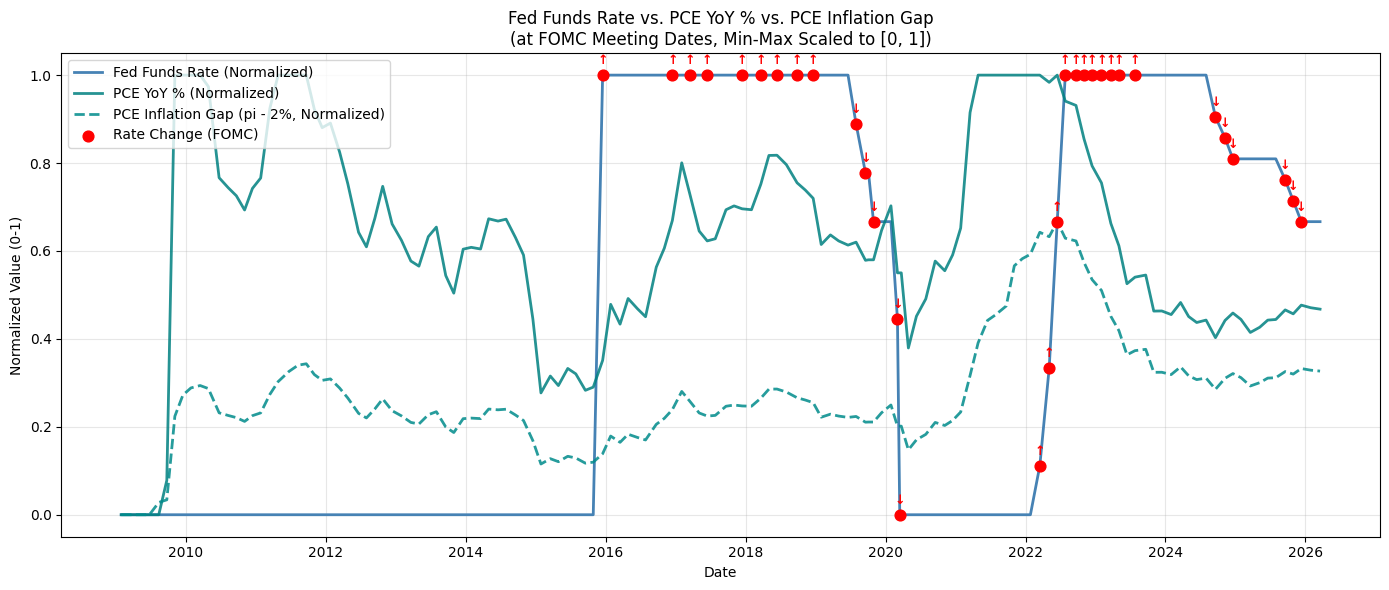


df_merged_all columns (PCE columns added):
['PCE_YoY_pct', 'PCE_inflation_gap', 'PCE_inflation_gap_normalized', 'PCE_YoY_normalized']


In [5]:
# Match PCE data to FOMC meeting dates via last-observation-carry-forward
pce_cols = ['PCE_YoY_pct', 'PCE_inflation_gap', 'PCE_inflation_gap_normalized', 'PCE_YoY_normalized']
df_meeting_pce = locf_match(
    df_pce, 'observation_date',
    ['PCE_YoY_pct', 'PCE_inflation_gap', 'PCE_inflation_gap_normalized'],
    df_merged['meeting_date'],
)

_base = df_merged_all if 'df_merged_all' in globals() else df_merged
_base = _base.drop(columns=pce_cols, errors='ignore')
df_merged_all = pd.merge(_base, df_meeting_pce, on='meeting_date', how='left', validate='one_to_one')

# Normalize PCE YoY for the combined chart
df_merged_all['PCE_YoY_normalized'] = minmax_normalize(df_merged_all['PCE_YoY_pct'])

# Combined line chart: PCE YoY, PCE Inflation Gap (normalized), Fed Funds Rate
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_merged_all['meeting_date'], df_merged_all['target_rate_normalized'],
        color='steelblue', linewidth=2, label='Fed Funds Rate (Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['PCE_YoY_normalized'],
        color='teal', linewidth=2, alpha=0.85, label='PCE YoY % (Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['PCE_inflation_gap_normalized'],
        color='darkcyan', linewidth=2, alpha=0.85, linestyle='--',
        label='PCE Inflation Gap (pi - 2%, Normalized)')

changed = df_merged_all[df_merged_all['decision'].isin(['higher', 'lower'])]
ax.scatter(changed['meeting_date'], changed['target_rate_normalized'],
           color='red', s=60, zorder=6, label='Rate Change (FOMC)')
for _, row in changed.iterrows():
    symbol = '↑' if row['decision'] == 'higher' else '↓'
    if not pd.isna(row['target_rate_normalized']):
        ax.annotate(symbol, xy=(row['meeting_date'], row['target_rate_normalized']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='red', fontweight='bold')

ax.set_title('Fed Funds Rate vs. PCE YoY % vs. PCE Inflation Gap\n'
             '(at FOMC Meeting Dates, Min-Max Scaled to [0, 1])')
ax.set_xlabel('Date'); ax.set_ylabel('Normalized Value (0-1)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\ndf_merged_all columns (PCE columns added):")
print([c for c in df_merged_all.columns if 'PCE' in c])


### Incorporating Unemployment Gap

We compute the **Unemployment Gap** as the difference between the actual unemployment rate (UNRATE) and
the Non-Accelerating Inflation Rate of Unemployment (NROU):

$$\text{Unemployment Gap}_t = \text{UNRATE}_t - \text{NROU}_t$$

A positive gap (UNRATE > NROU) signals a slack labour market; a negative gap indicates an overheated one.

Sources:
- UNRATE: https://fred.stlouisfed.org/series/UNRATE  
- NROU: https://fred.stlouisfed.org/series/NROU

Unemployment Gap data: 1949-01-01 → 2026-03-01

Sample rows:


,observation_date,UNRATE,NROU,unemployment_gap
916,2025-05-01,4.3,4.406004,-0.106004
917,2025-06-01,4.1,4.405102,-0.305102
918,2025-07-01,4.3,4.404200,-0.104200
919,2025-08-01,4.3,4.403414,-0.103414
920,2025-09-01,4.4,4.402627,-0.002627
921,2025-11-01,4.5,4.400924,0.099076
922,2025-12-01,4.4,4.400007,-0.000007
923,2026-01-01,4.3,4.399091,-0.099091
924,2026-02-01,4.4,4.398038,0.001962
925,2026-03-01,4.3,4.396985,-0.096985


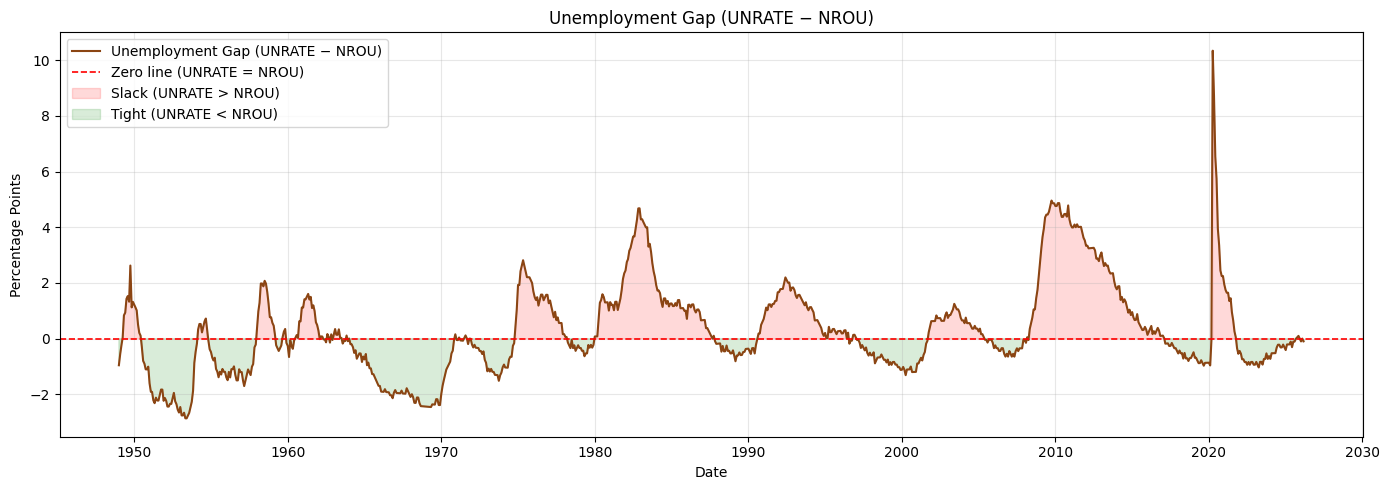

In [6]:
# Load UNRATE (monthly)
unrate_path = resolve_data_source('Unemployment Rate UNRATE all.csv', PROJECT_ROOT)
df_unrate = pd.read_csv(unrate_path)
df_unrate['observation_date'] = pd.to_datetime(df_unrate['observation_date'])
df_unrate['UNRATE'] = pd.to_numeric(df_unrate['UNRATE'], errors='coerce')
df_unrate = df_unrate.dropna(subset=['UNRATE']).sort_values('observation_date').reset_index(drop=True)

# Load NROU (quarterly) and interpolate to monthly
nrou_path = resolve_data_source('Noncyclical Rate of Unemployment.csv', PROJECT_ROOT)
df_nrou = pd.read_csv(nrou_path)
df_nrou['observation_date'] = pd.to_datetime(df_nrou['observation_date'])
df_nrou['NROU'] = pd.to_numeric(df_nrou['NROU'], errors='coerce')
df_nrou = df_nrou.dropna(subset=['NROU']).sort_values('observation_date').set_index('observation_date')

# Upsample NROU from quarterly to monthly via linear interpolation
df_nrou_monthly = df_nrou.resample('MS').interpolate(method='linear').reset_index()

# Compute Unemployment Gap = UNRATE - NROU
df_ugap = pd.merge(df_unrate, df_nrou_monthly, on='observation_date', how='inner')
df_ugap['unemployment_gap'] = df_ugap['UNRATE'] - df_ugap['NROU']

print(f"Unemployment Gap data: {df_ugap['observation_date'].min().date()} \u2192 {df_ugap['observation_date'].max().date()}")
print(f"\nSample rows:")
display(df_ugap[['observation_date', 'UNRATE', 'NROU', 'unemployment_gap']].tail(10))

# Plot raw unemployment gap
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_ugap['observation_date'], df_ugap['unemployment_gap'],
        color='saddlebrown', linewidth=1.5, label='Unemployment Gap (UNRATE \u2212 NROU)')
ax.axhline(y=0, color='red', linewidth=1.2, linestyle='--', label='Zero line (UNRATE = NROU)')
ax.fill_between(df_ugap['observation_date'], df_ugap['unemployment_gap'], 0,
                where=(df_ugap['unemployment_gap'] > 0),
                alpha=0.15, color='red', label='Slack (UNRATE > NROU)')
ax.fill_between(df_ugap['observation_date'], df_ugap['unemployment_gap'], 0,
                where=(df_ugap['unemployment_gap'] <= 0),
                alpha=0.15, color='green', label='Tight (UNRATE < NROU)')
ax.set_title('Unemployment Gap (UNRATE \u2212 NROU)')
ax.set_xlabel('Date')
ax.set_ylabel('Percentage Points')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

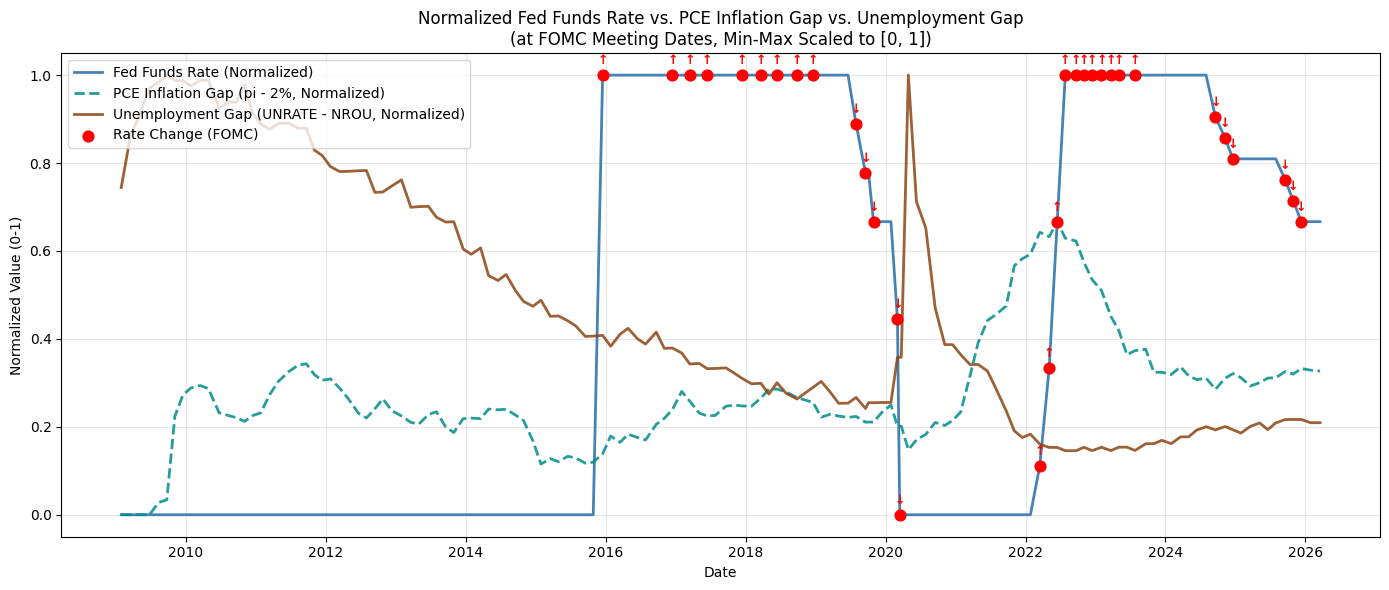


df_merged_all columns (unemployment gap added):
['unemployment_gap', 'unemployment_gap_normalized']


In [7]:
# Normalize unemployment gap
df_ugap['unemployment_gap_normalized'] = minmax_normalize(df_ugap['unemployment_gap'])

# Match unemployment gap to FOMC meeting dates via last-observation-carry-forward
ugap_cols = ['unemployment_gap', 'unemployment_gap_normalized']
df_meeting_ugap = locf_match(
    df_ugap, 'observation_date',
    ugap_cols,
    df_merged['meeting_date'],
)
_base = df_merged_all.drop(columns=ugap_cols, errors='ignore')
df_merged_all = pd.merge(_base, df_meeting_ugap, on='meeting_date', how='left', validate='one_to_one')

# Combined line chart: Fed Funds Rate + PCE Inflation Gap + Unemployment Gap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_merged_all['meeting_date'], df_merged_all['target_rate_normalized'],
        color='steelblue', linewidth=2, label='Fed Funds Rate (Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['PCE_inflation_gap_normalized'],
        color='darkcyan', linewidth=2, alpha=0.85, linestyle='--',
        label='PCE Inflation Gap (pi - 2%, Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['unemployment_gap_normalized'],
        color='saddlebrown', linewidth=2, alpha=0.85,
        label='Unemployment Gap (UNRATE - NROU, Normalized)')

changed = df_merged_all[df_merged_all['decision'].isin(['higher', 'lower'])]
ax.scatter(changed['meeting_date'], changed['target_rate_normalized'],
           color='red', s=60, zorder=6, label='Rate Change (FOMC)')
for _, row in changed.iterrows():
    symbol = '↑' if row['decision'] == 'higher' else '↓'
    if not pd.isna(row['target_rate_normalized']):
        ax.annotate(symbol, xy=(row['meeting_date'], row['target_rate_normalized']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='red', fontweight='bold')

ax.set_title('Normalized Fed Funds Rate vs. PCE Inflation Gap vs. Unemployment Gap\n'
             '(at FOMC Meeting Dates, Min-Max Scaled to [0, 1])')
ax.set_xlabel('Date'); ax.set_ylabel('Normalized Value (0-1)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\ndf_merged_all columns (unemployment gap added):")
print([c for c in df_merged_all.columns if 'unemployment' in c.lower()])


### Incorporating Output Gap (GDP Gap)

We compute the **Output Gap** as the percentage deviation of Real GDP from its potential:

$$\text{Output Gap}_t = 100 \times \frac{\text{GDPC1}_t - \text{GDPPOT}_t}{\text{GDPPOT}_t}$$

A positive gap indicates an overheating economy (actual > potential); a negative gap signals slack / recession territory.

Sources:
- GDPC1 (Real GDP): https://fred.stlouisfed.org/series/GDPC1  
- GDPPOT (Real Potential GDP): https://fred.stlouisfed.org/series/GDPPOT

Output Gap data: 1949-01-01 → 2025-10-01

Sample rows:


,observation_date,GDPC1,GDPPOT,output_gap_pct
298,2023-07-01,22840.989,22527.570931,1.391264
299,2023-10-01,23033.780,22678.156520,1.568132
300,2024-01-01,23082.119,22828.945411,1.109003
301,2024-04-01,23286.508,22979.033391,1.338066
302,2024-07-01,23478.570,23126.896106,1.520627
303,2024-10-01,23586.542,23271.541687,1.353586
304,2025-01-01,23548.210,23414.656420,0.570385
305,2025-04-01,23770.976,23548.517662,0.944681
306,2025-07-01,24026.834,23680.152477,1.464017
307,2025-10-01,24055.749,23811.223897,1.026932


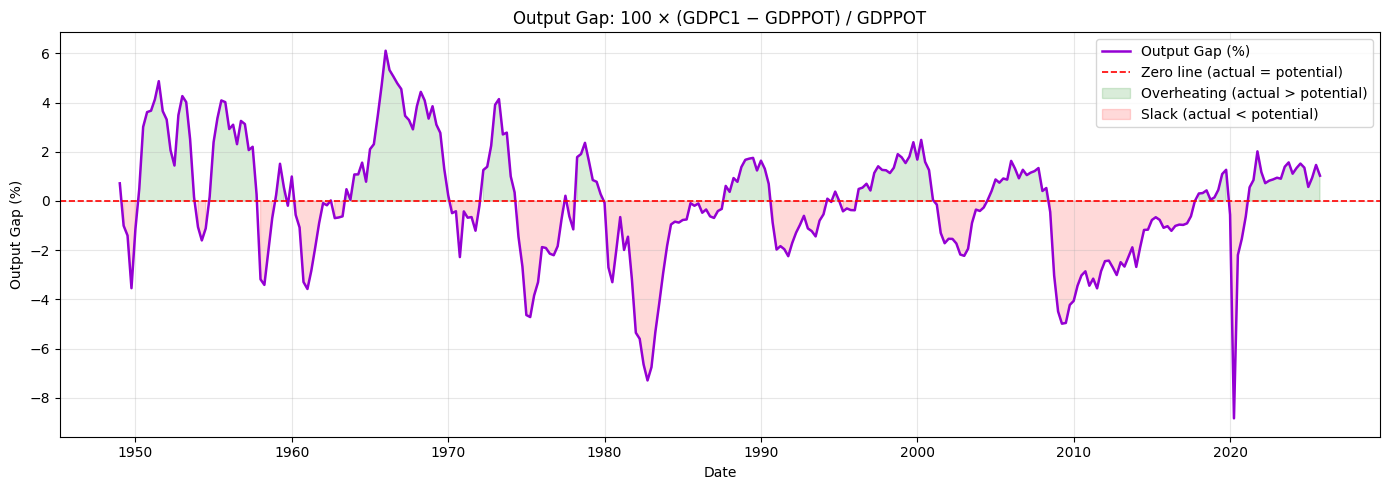

In [8]:
# Load Real GDP (quarterly)
gdp_path = resolve_data_source('Real GDP Data.csv', PROJECT_ROOT)
df_gdp = pd.read_csv(gdp_path)
df_gdp['observation_date'] = pd.to_datetime(df_gdp['observation_date'])
df_gdp['GDPC1'] = pd.to_numeric(df_gdp['GDPC1'], errors='coerce')
df_gdp = df_gdp.dropna(subset=['GDPC1']).sort_values('observation_date').reset_index(drop=True)

# Load Real Potential GDP (quarterly)
pot_path = resolve_data_source('Real Potential GDP.csv', PROJECT_ROOT)
df_pot = pd.read_csv(pot_path)
df_pot['observation_date'] = pd.to_datetime(df_pot['observation_date'])
df_pot['GDPPOT'] = pd.to_numeric(df_pot['GDPPOT'], errors='coerce')
df_pot = df_pot.dropna(subset=['GDPPOT']).sort_values('observation_date').reset_index(drop=True)

# Merge on date and compute Output Gap
df_gdpgap = pd.merge(df_gdp, df_pot, on='observation_date', how='inner')
df_gdpgap['output_gap_pct'] = 100.0 * (df_gdpgap['GDPC1'] - df_gdpgap['GDPPOT']) / df_gdpgap['GDPPOT']

print(f"Output Gap data: {df_gdpgap['observation_date'].min().date()} \u2192 {df_gdpgap['observation_date'].max().date()}")
print(f"\nSample rows:")
display(df_gdpgap[['observation_date', 'GDPC1', 'GDPPOT', 'output_gap_pct']].tail(10))

# --- Individual line chart: Output Gap % ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_gdpgap['observation_date'], df_gdpgap['output_gap_pct'],
        color='darkviolet', linewidth=1.8, label='Output Gap (%)')
ax.axhline(y=0, color='red', linewidth=1.2, linestyle='--', label='Zero line (actual = potential)')
ax.fill_between(df_gdpgap['observation_date'], df_gdpgap['output_gap_pct'], 0,
                where=(df_gdpgap['output_gap_pct'] > 0),
                alpha=0.15, color='green', label='Overheating (actual > potential)')
ax.fill_between(df_gdpgap['observation_date'], df_gdpgap['output_gap_pct'], 0,
                where=(df_gdpgap['output_gap_pct'] <= 0),
                alpha=0.15, color='red', label='Slack (actual < potential)')
ax.set_title('Output Gap: 100 \u00d7 (GDPC1 \u2212 GDPPOT) / GDPPOT')
ax.set_xlabel('Date')
ax.set_ylabel('Output Gap (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

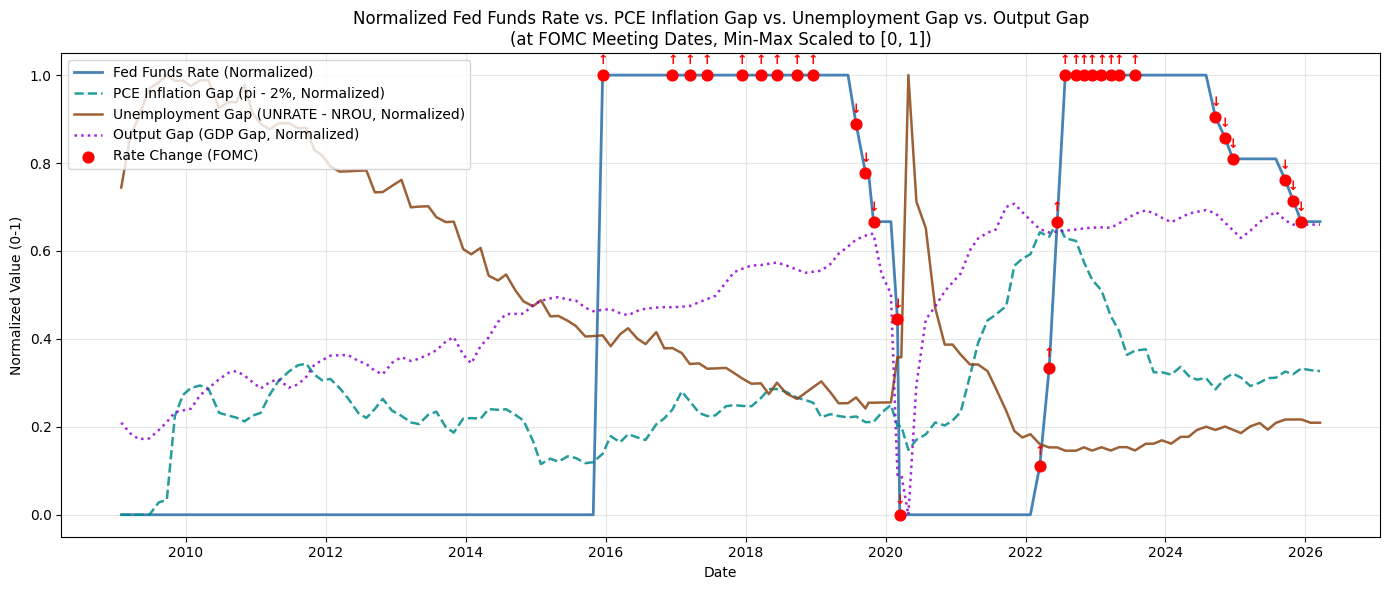


df_merged_all columns (output gap added):
['output_gap_pct', 'output_gap_normalized']


In [9]:
# Upsample quarterly Output Gap to monthly via linear interpolation
df_gdpgap_monthly = (
    df_gdpgap[['observation_date', 'output_gap_pct']]
    .set_index('observation_date')
    .resample('MS')
    .interpolate(method='linear')
    .reset_index()
)

# Normalize output gap
ogap_cols = ['output_gap_pct', 'output_gap_normalized']
df_gdpgap_monthly['output_gap_normalized'] = minmax_normalize(df_gdpgap_monthly['output_gap_pct'])

# Match output gap to FOMC meeting dates via last-observation-carry-forward
df_meeting_ogap = locf_match(
    df_gdpgap_monthly, 'observation_date',
    ogap_cols,
    df_merged['meeting_date'],
)
_base = df_merged_all.drop(columns=ogap_cols, errors='ignore')
df_merged_all = pd.merge(_base, df_meeting_ogap, on='meeting_date', how='left', validate='one_to_one')

# Combined line chart: Fed Rate + PCE Gap + Unemployment Gap + Output Gap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_merged_all['meeting_date'], df_merged_all['target_rate_normalized'],
        color='steelblue', linewidth=2.0, label='Fed Funds Rate (Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['PCE_inflation_gap_normalized'],
        color='darkcyan', linewidth=1.8, linestyle='--', alpha=0.85,
        label='PCE Inflation Gap (pi - 2%, Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['unemployment_gap_normalized'],
        color='saddlebrown', linewidth=1.8, alpha=0.85,
        label='Unemployment Gap (UNRATE - NROU, Normalized)')
ax.plot(df_merged_all['meeting_date'], df_merged_all['output_gap_normalized'],
        color='darkviolet', linewidth=1.8, linestyle=':', alpha=0.85,
        label='Output Gap (GDP Gap, Normalized)')

changed = df_merged_all[df_merged_all['decision'].isin(['higher', 'lower'])]
ax.scatter(changed['meeting_date'], changed['target_rate_normalized'],
           color='red', s=60, zorder=6, label='Rate Change (FOMC)')
for _, row in changed.iterrows():
    symbol = '↑' if row['decision'] == 'higher' else '↓'
    if not pd.isna(row['target_rate_normalized']):
        ax.annotate(symbol, xy=(row['meeting_date'], row['target_rate_normalized']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='red', fontweight='bold')

ax.set_title(
    'Normalized Fed Funds Rate vs. PCE Inflation Gap vs. Unemployment Gap vs. Output Gap\n'
    '(at FOMC Meeting Dates, Min-Max Scaled to [0, 1])'
)
ax.set_xlabel('Date'); ax.set_ylabel('Normalized Value (0-1)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\ndf_merged_all columns (output gap added):")
print([c for c in df_merged_all.columns if 'output_gap' in c.lower()])


NFCI data: 1971-01-08 -> 2026-04-10
Monthly observations: 664


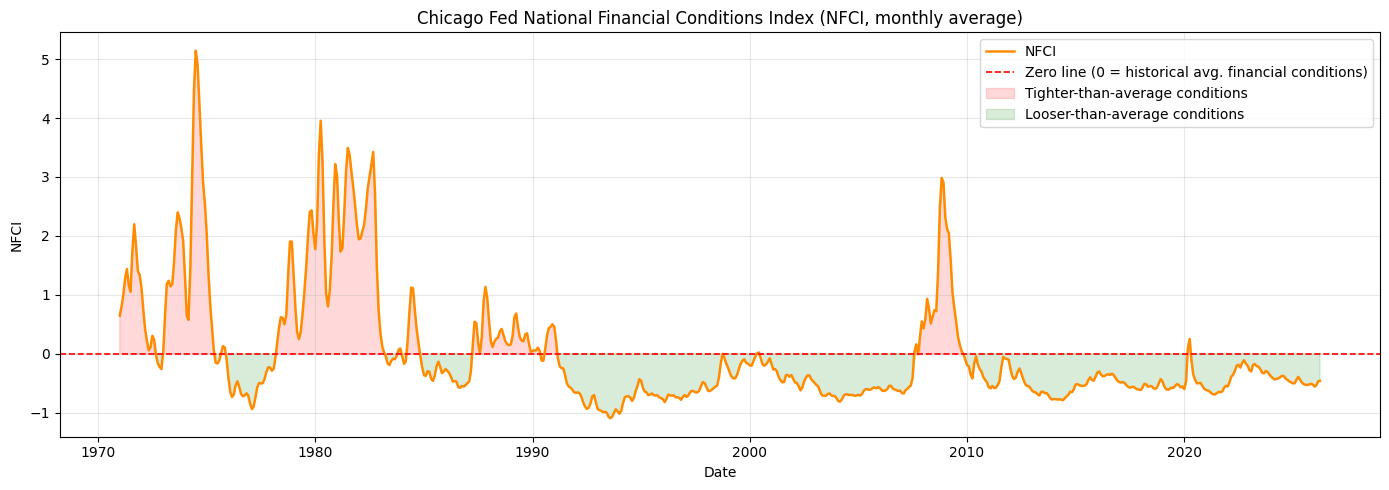


df_merged_all NFCI columns: ['NFCI', 'NFCI_normalized']


In [10]:
# Load and Process Chicago Fed National Financial Conditions Index (NFCI)
nfci_path = resolve_data_source('Chicago Fed NFCI.csv', PROJECT_ROOT)
df_nfci = pd.read_csv(nfci_path)
df_nfci['observation_date'] = pd.to_datetime(df_nfci['observation_date'])
df_nfci['NFCI'] = pd.to_numeric(df_nfci['NFCI'], errors='coerce')
df_nfci = df_nfci.dropna(subset=['NFCI']).sort_values('observation_date').reset_index(drop=True)

# Resample weekly -> monthly (mean of all weeks in month)
df_nfci_monthly = (
    df_nfci[['observation_date', 'NFCI']]
    .set_index('observation_date')
    .resample('MS')
    .mean()
    .reset_index()
)

# Normalize NFCI (min-max scaling)
nfci_cols = ['NFCI', 'NFCI_normalized']
df_nfci_monthly['NFCI_normalized'] = minmax_normalize(df_nfci_monthly['NFCI'])

# Match to FOMC meeting dates via last-observation-carry-forward
df_meeting_nfci = locf_match(
    df_nfci_monthly, 'observation_date',
    nfci_cols,
    df_merged['meeting_date'],
)
_base = df_merged_all.drop(columns=nfci_cols, errors='ignore')
df_merged_all = pd.merge(_base, df_meeting_nfci, on='meeting_date', how='left', validate='one_to_one')

print(f"NFCI data: {df_nfci['observation_date'].min().date()} -> {df_nfci['observation_date'].max().date()}")
print(f"Monthly observations: {len(df_nfci_monthly)}")

# Individual NFCI chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_nfci_monthly['observation_date'], df_nfci_monthly['NFCI'],
        color='darkorange', linewidth=1.8, label='NFCI')
ax.axhline(y=0, color='red', linewidth=1.2, linestyle='--',
           label='Zero line (0 = historical avg. financial conditions)')
ax.fill_between(df_nfci_monthly['observation_date'], df_nfci_monthly['NFCI'], 0,
                where=(df_nfci_monthly['NFCI'] > 0),
                alpha=0.15, color='red', label='Tighter-than-average conditions')
ax.fill_between(df_nfci_monthly['observation_date'], df_nfci_monthly['NFCI'], 0,
                where=(df_nfci_monthly['NFCI'] <= 0),
                alpha=0.15, color='green', label='Looser-than-average conditions')
ax.set_title('Chicago Fed National Financial Conditions Index (NFCI, monthly average)')
ax.set_xlabel('Date')
ax.set_ylabel('NFCI')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\ndf_merged_all NFCI columns:", [c for c in df_merged_all.columns if 'NFCI' in c])


### Raw Variables: Fed Funds Rate, PCE Inflation Gap, Unemployment Gap, Output Gap

Before normalizing, we plot each core variable in its natural units to preserve economic interpretability.

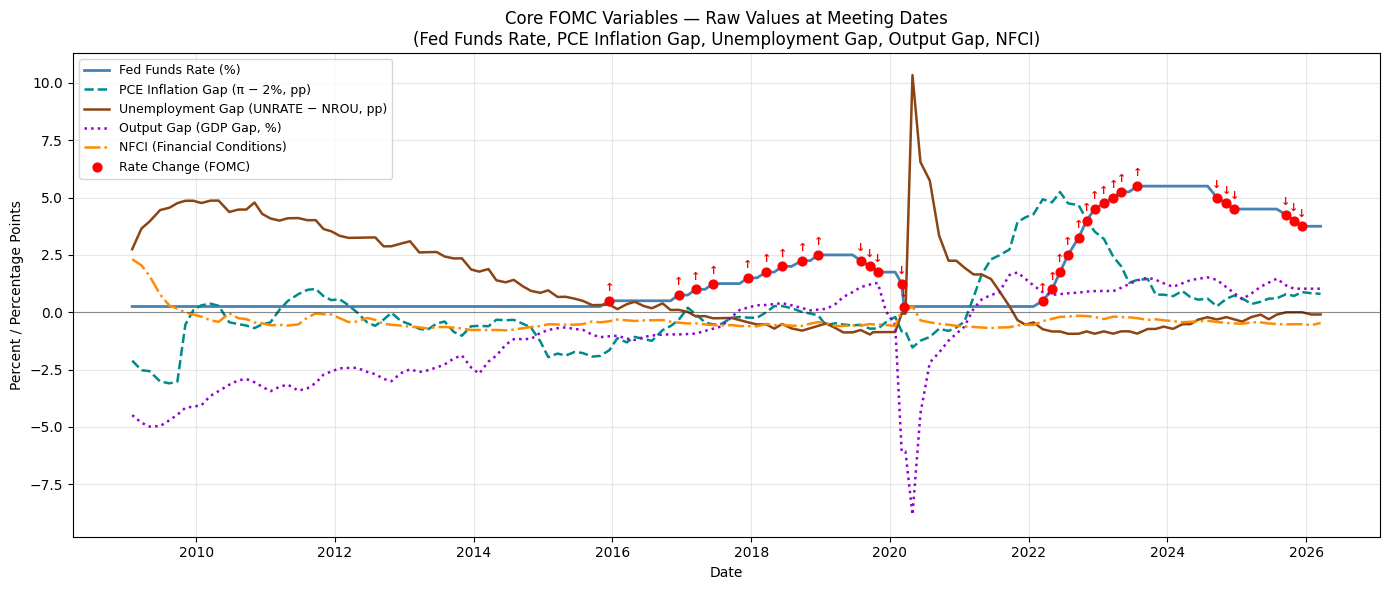

In [11]:
# Raw (unnormalized) variables plot at FOMC meeting dates.
# Self-contained: recreates df_ugap from raw GitHub data if an earlier cell was skipped.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Ensure df_ugap is available ──────────────────────────────────────────────
if 'df_ugap' not in globals() or not isinstance(df_ugap, pd.DataFrame):
    _unrate = pd.read_csv(resolve_data_source('Unemployment Rate UNRATE all.csv', PROJECT_ROOT))
    _unrate['observation_date'] = pd.to_datetime(_unrate['observation_date'])
    _unrate['UNRATE'] = pd.to_numeric(_unrate['UNRATE'], errors='coerce')
    _unrate = _unrate.dropna(subset=['UNRATE']).sort_values('observation_date').reset_index(drop=True)

    _nrou = pd.read_csv(resolve_data_source('Noncyclical Rate of Unemployment.csv', PROJECT_ROOT))
    _nrou['observation_date'] = pd.to_datetime(_nrou['observation_date'])
    _nrou['NROU'] = pd.to_numeric(_nrou['NROU'], errors='coerce')
    _nrou = (_nrou.dropna(subset=['NROU'])
                  .sort_values('observation_date')
                  .set_index('observation_date')
                  .resample('MS').interpolate(method='linear')
                  .reset_index())

    df_ugap = pd.merge(_unrate, _nrou, on='observation_date', how='inner')
    df_ugap['unemployment_gap'] = df_ugap['UNRATE'] - df_ugap['NROU']
    print("df_ugap recreated from raw GitHub data URLs.")

# ── Build plotting frame via locf_match (defined in cell 1) ──────────────────
meeting_dates = df_merged['meeting_date']
df_plt = df_merged[['meeting_date', 'target_rate', 'decision']].copy()

df_pce_m  = locf_match(df_pce,            'observation_date', ['PCE_inflation_gap'], meeting_dates)
df_ugap_m = locf_match(df_ugap,           'observation_date', ['unemployment_gap'],  meeting_dates)
df_ogap_m  = locf_match(df_gdpgap_monthly, 'observation_date', ['output_gap_pct'],    meeting_dates)
df_nfci_m  = locf_match(df_nfci_monthly,    'observation_date', ['NFCI'],             meeting_dates)

df_plt = (df_plt
          .merge(df_pce_m,  on='meeting_date', how='left')
          .merge(df_ugap_m, on='meeting_date', how='left')
          .merge(df_ogap_m, on='meeting_date', how='left')
          .merge(df_nfci_m, on='meeting_date', how='left'))

# ── Single combined raw-values panel ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_plt['meeting_date'], df_plt['target_rate'],
        color='steelblue',   linewidth=2.0, label='Fed Funds Rate (%)')
ax.plot(df_plt['meeting_date'], df_plt['PCE_inflation_gap'],
        color='darkcyan',    linewidth=1.8, linestyle='--', label='PCE Inflation Gap (π − 2%, pp)')
ax.plot(df_plt['meeting_date'], df_plt['unemployment_gap'],
        color='saddlebrown', linewidth=1.8, label='Unemployment Gap (UNRATE − NROU, pp)')
ax.plot(df_plt['meeting_date'], df_plt['output_gap_pct'],
        color='darkviolet',  linewidth=1.8, linestyle=':', label='Output Gap (GDP Gap, %)')
ax.plot(df_plt['meeting_date'], df_plt['NFCI'],
        color='darkorange',  linewidth=1.8, linestyle='-.', label='NFCI (Financial Conditions)')

ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.4)

changed = df_plt[df_plt['decision'].isin(['higher', 'lower'])]
ax.scatter(changed['meeting_date'], changed['target_rate'],
           color='red', s=40, zorder=6, label='Rate Change (FOMC)')
for _, row in changed.iterrows():
    symbol = '↑' if row['decision'] == 'higher' else '↓'
    ax.annotate(symbol, xy=(row['meeting_date'], row['target_rate']),
                xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=8, color='red', fontweight='bold')

ax.set_title('Core FOMC Variables — Raw Values at Meeting Dates\n'
             '(Fed Funds Rate, PCE Inflation Gap, Unemployment Gap, Output Gap, NFCI)',
             fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Percent / Percentage Points')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Correlation Analysis: PCE Inflation Gap, Unemployment Gap, Output Gap

We examine pairwise correlations between the three core macroeconomic gap variables and the Fed Funds Rate to assess multicollinearity and sign alignment with FOMC theory.

Pearson Correlation Matrix:


,Fed Funds Rate,PCE Inflation Gap (π−2%),Unemployment Gap (UNRATE−NROU),Output Gap (%),NFCI (Financial Conditions)
Fed Funds Rate,1.000,0.368,-0.579,0.654,-0.051
PCE Inflation Gap (π−2%),0.368,1.000,-0.376,0.529,-0.201
Unemployment Gap (UNRATE−NROU),-0.579,-0.376,1.000,-0.818,0.278
Output Gap (%),0.654,0.529,-0.818,1.000,-0.442
NFCI (Financial Conditions),-0.051,-0.201,0.278,-0.442,1.000


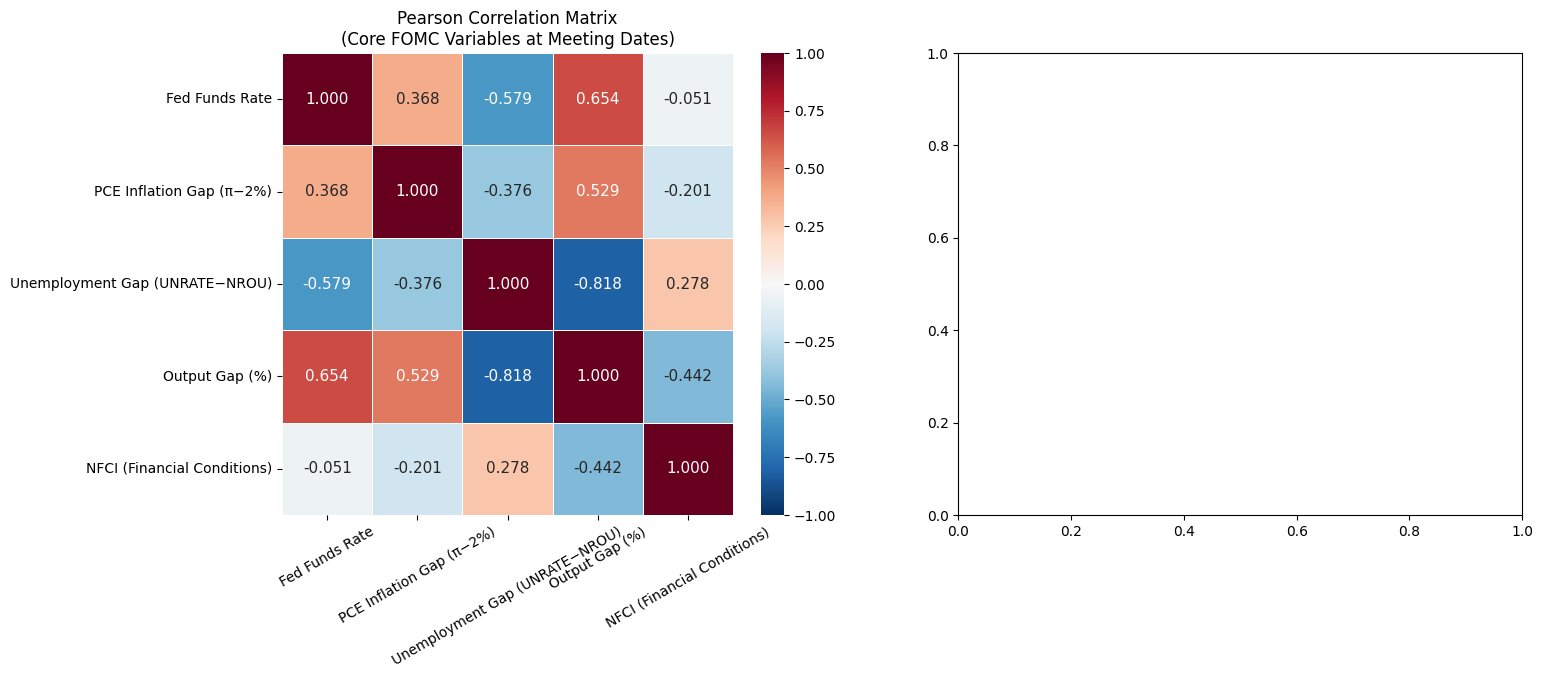

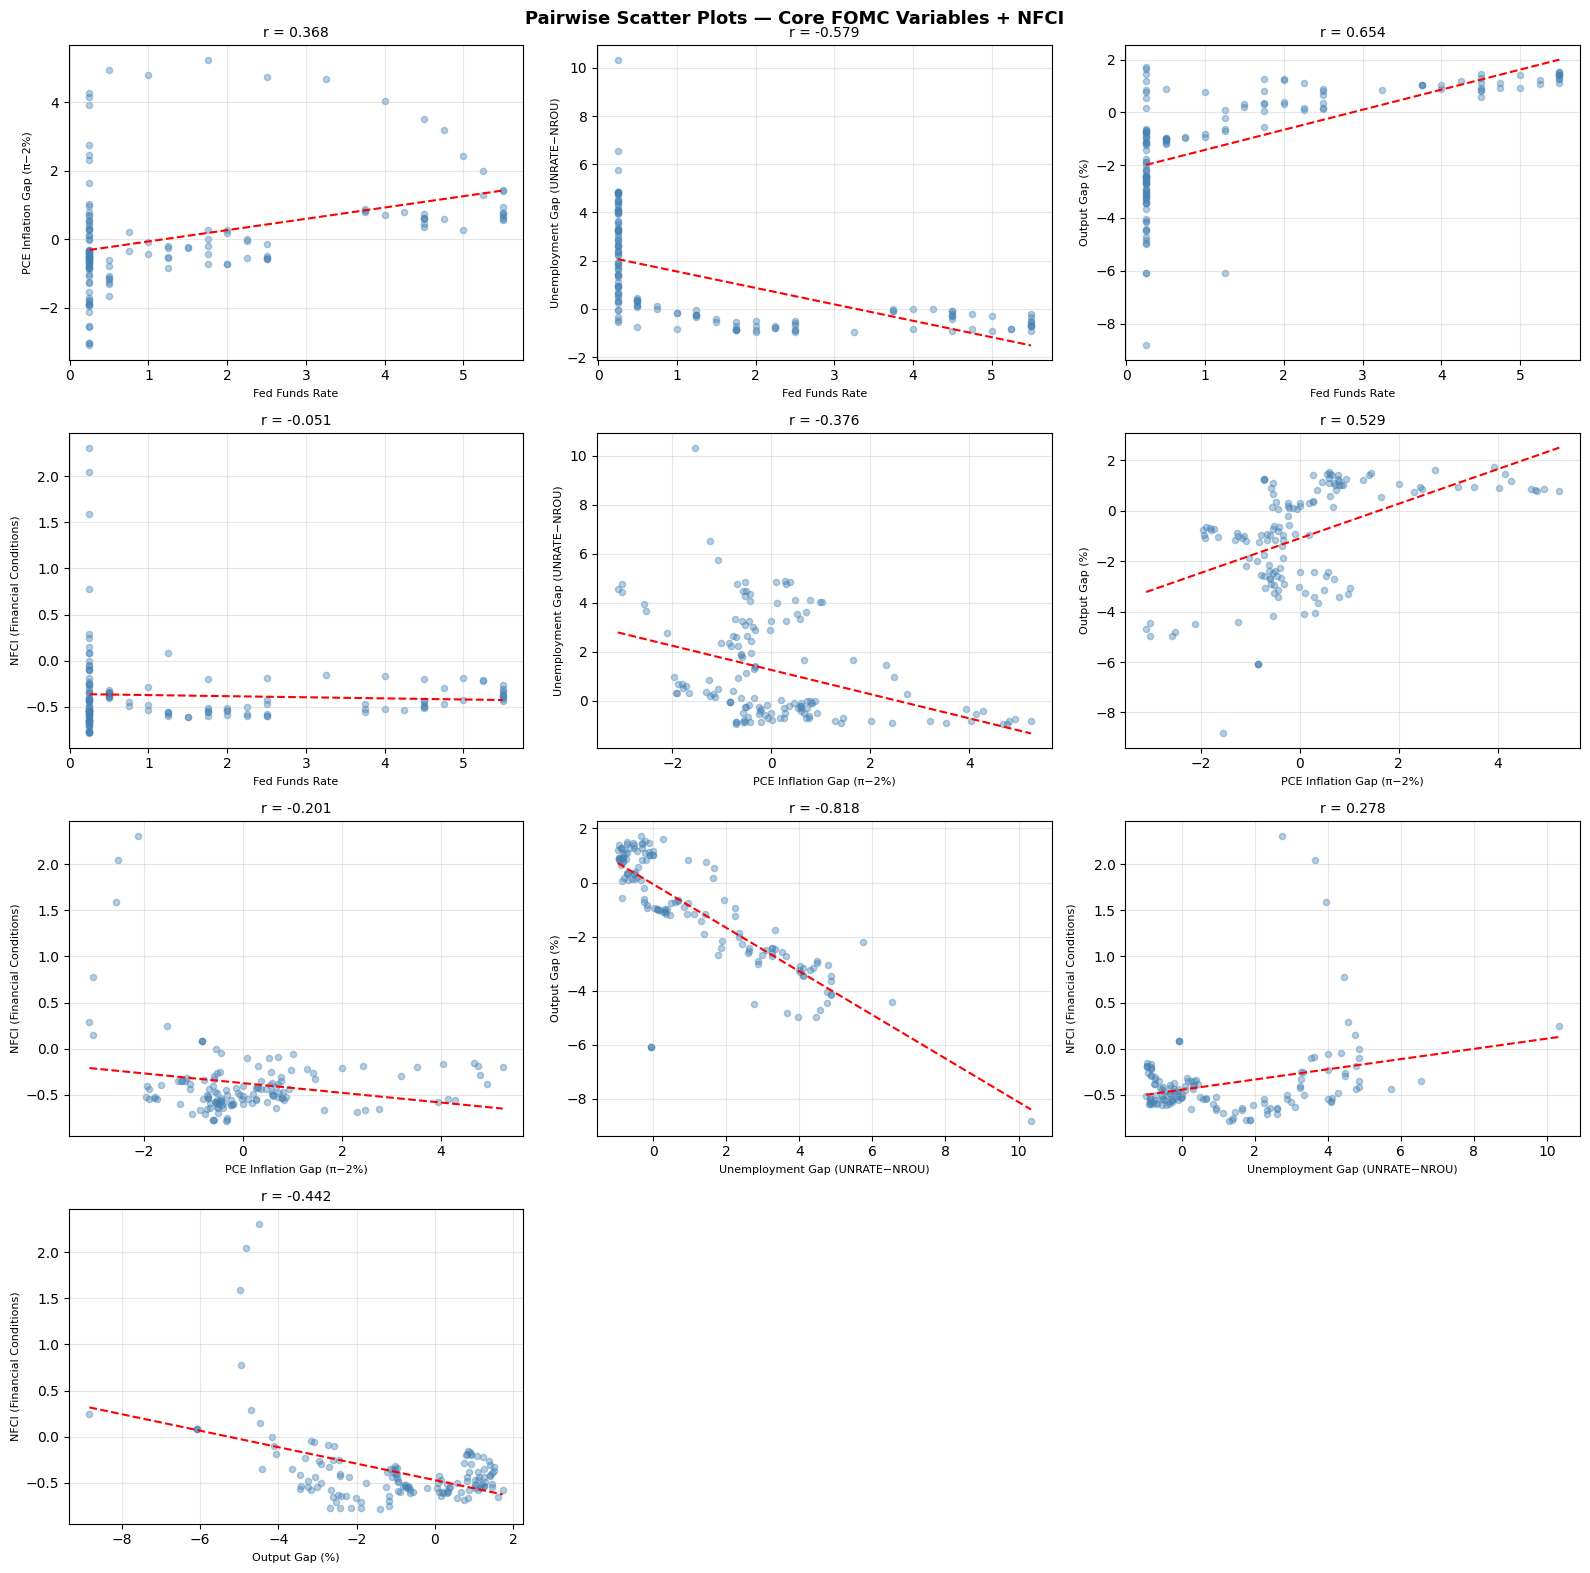


Sign interpretation (FOMC theory):
  PCE Inflation Gap ↑  →  Fed should hike (positive correlation with rate expected)
  Unemployment Gap ↑   →  Labor market slack, Fed likely cuts (negative correlation expected)
  Output Gap ↑         →  Overheating economy, Fed likely hikes (positive correlation expected)
  NFCI ↑               →  Tighter financial conditions, may restrain or accompany rate hikes (positive correlation expected)


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select core variables for correlation analysis
corr_vars = ['target_rate', 'PCE_inflation_gap', 'unemployment_gap', 'output_gap_pct', 'NFCI']
corr_labels = {
    'target_rate': 'Fed Funds Rate',
    'PCE_inflation_gap': 'PCE Inflation Gap (π−2%)',
    'unemployment_gap': 'Unemployment Gap (UNRATE−NROU)',
    'output_gap_pct': 'Output Gap (%)',
    'NFCI': 'NFCI (Financial Conditions)',
}

df_corr = df_merged_all[corr_vars].dropna().rename(columns=corr_labels)

# ── Pearson correlation matrix ───────────────────────────────────────────────
corr_matrix = df_corr.corr()
print("Pearson Correlation Matrix:")
display(corr_matrix.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 11})
axes[0].set_title('Pearson Correlation Matrix\n(Core FOMC Variables at Meeting Dates)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Pairplot-style scatter matrix via scatter + regression lines
import itertools
pairs = list(itertools.combinations(df_corr.columns, 2))
n = len(pairs)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig2, axes2 = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes2 = axes2.flatten()

for idx, (x_col, y_col) in enumerate(pairs):
    ax = axes2[idx]
    ax.scatter(df_corr[x_col], df_corr[y_col], alpha=0.4, s=20, color='steelblue')
    # Regression line
    m, b = np.polyfit(df_corr[x_col].dropna(), df_corr[y_col].dropna(), 1)
    x_range = np.linspace(df_corr[x_col].min(), df_corr[x_col].max(), 100)
    ax.plot(x_range, m * x_range + b, color='red', linewidth=1.5, linestyle='--')
    r = corr_matrix.loc[x_col, y_col]
    ax.set_title(f'r = {r:.3f}', fontsize=10)
    ax.set_xlabel(x_col, fontsize=8)
    ax.set_ylabel(y_col, fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(pairs), len(axes2)):
    axes2[idx].set_visible(False)

fig2.suptitle('Pairwise Scatter Plots — Core FOMC Variables + NFCI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary interpretation ───────────────────────────────────────────────────
print("\nSign interpretation (FOMC theory):")
print("  PCE Inflation Gap ↑  →  Fed should hike (positive correlation with rate expected)")
print("  Unemployment Gap ↑   →  Labor market slack, Fed likely cuts (negative correlation expected)")
print("  Output Gap ↑         →  Overheating economy, Fed likely hikes (positive correlation expected)")
print("  NFCI ↑               →  Tighter financial conditions, may restrain or accompany rate hikes (positive correlation expected)")

## Part B — Feature Engineering (Lags, Trends, Policy Inertia)

Here we build boosting-model features from the current meeting-level variable set only.
All predictors are based strictly on information available before meeting `t`, including the natural policy lag

\[
\text{Lagged UpperBound}_t = \text{UpperBound}_{t-1}
\]

so the model can learn policy inertia without leakage.


In [13]:
# Feature Engineering — build modeling dataframe from df_merged_all
# Map decision labels to numeric values (+1 = hike, 0 = hold, -1 = cut)
decision_map = {'higher': 1, 'same': 0, 'lower': -1}
df_merged_all['decision_num'] = df_merged_all['decision'].map(decision_map)

feature_cols = [
    'target_rate',
    'PCE_inflation_gap',
    'unemployment_gap',
    'output_gap_pct',
    'NFCI',
]

# Build a clean modeling frame from the current variable set
df_model = df_merged_all[
    ['meeting_date', 'decision', 'decision_num'] + feature_cols
].copy()

MAX_LAG = 4

# Meeting-to-meeting lags for all core variables
for col in feature_cols:
    for lag in range(1, MAX_LAG + 1):
        df_model[f'{col}_lag{lag}'] = df_model[col].shift(lag)

# Natural policy lag for boosting models: Lagged UpperBound_t = UpperBound_{t-1}
df_model['lagged_upper_bound'] = df_model['target_rate_lag1']

# Change features built only from lagged information
df_model['PCE_gap_change_1m'] = df_model['PCE_inflation_gap_lag1'] - df_model['PCE_inflation_gap_lag2']
df_model['unemployment_gap_change_1m'] = df_model['unemployment_gap_lag1'] - df_model['unemployment_gap_lag2']
df_model['output_gap_change_1q'] = df_model['output_gap_pct_lag1'] - df_model['output_gap_pct_lag2']
df_model['nfci_change_1m'] = df_model['NFCI_lag1'] - df_model['NFCI_lag2']

display(df_model.head())


,meeting_date,decision,decision_num,target_rate,PCE_inflation_gap,unemployment_gap,output_gap_pct,NFCI,target_rate_lag1,target_rate_lag2,...,output_gap_pct_lag4,NFCI_lag1,NFCI_lag2,NFCI_lag3,NFCI_lag4,lagged_upper_bound,PCE_gap_change_1m,unemployment_gap_change_1m,output_gap_change_1q,nfci_change_1m
0,2009-01-28,NaN,NaN,0.25,-2.111104,2.752117,-4.486292,2.31060,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-03-18,same,0.0,0.25,-2.525752,3.653187,-4.818655,2.04600,0.25,NaN,...,NaN,2.31060,NaN,NaN,NaN,0.25,NaN,NaN,NaN,NaN
2,2009-04-29,same,0.0,0.25,-2.567574,3.953722,-4.984837,1.58725,0.25,0.25,...,NaN,2.04600,2.31060,NaN,NaN,0.25,-0.414648,0.901070,-0.332363,-0.26460
3,2009-06-24,same,0.0,0.25,-3.018625,4.455281,-4.964902,0.77575,0.25,0.25,...,NaN,1.58725,2.04600,2.3106,NaN,0.25,-0.041822,0.300535,-0.166181,-0.45875
4,2009-08-12,same,0.0,0.25,-3.100120,4.557112,-4.710832,0.29075,0.25,0.25,...,-4.486292,0.77575,1.58725,2.0460,2.3106,0.25,-0.451051,0.501559,0.019935,-0.81150


In [14]:
# Policy inertia / duration features
df_model['prev_decision'] = df_model['decision'].shift(1)
df_model['prev_decision_num'] = df_model['decision_num'].shift(1)

time_since_last_change = []
consecutive_same_list = []
steps_since_last_change = 0
consecutive_same = 0

for curr in df_model['decision_num'].to_numpy():
    time_since_last_change.append(steps_since_last_change)
    consecutive_same_list.append(consecutive_same)
    if not np.isnan(curr):
        if curr != 0:
            steps_since_last_change = 0
            consecutive_same = 0
        else:
            steps_since_last_change += 1
            consecutive_same += 1

df_model['time_since_last_change'] = time_since_last_change
df_model['consecutive_same'] = consecutive_same_list

# Keep only lagged predictors and labels; drop current-meeting raw features to avoid leakage
drop_cols = ['target_rate', 'PCE_inflation_gap', 'unemployment_gap', 'output_gap_pct', 'NFCI']
df_model = df_model.drop(columns=drop_cols)

# Lagged features require a short burn-in window
df_model = df_model.dropna().reset_index(drop=True)

print('Final feature columns:')
print(df_model.columns.tolist())
print('Shape of final modeling DataFrame:', df_model.shape)
display(df_model.head())
display(df_model.describe(include='all'))

csv_out = data_output_path('df_model.csv', PROJECT_ROOT)
parquet_out = data_output_path('df_model.parquet', PROJECT_ROOT)
df_model.to_csv(csv_out, index=False)
df_model.to_parquet(parquet_out, index=False)
print(f'Exported df_model to {csv_out}')
print(f'Exported df_model to {parquet_out}')


Final feature columns:
['meeting_date', 'decision', 'decision_num', 'target_rate_lag1', 'target_rate_lag2', 'target_rate_lag3', 'target_rate_lag4', 'PCE_inflation_gap_lag1', 'PCE_inflation_gap_lag2', 'PCE_inflation_gap_lag3', 'PCE_inflation_gap_lag4', 'unemployment_gap_lag1', 'unemployment_gap_lag2', 'unemployment_gap_lag3', 'unemployment_gap_lag4', 'output_gap_pct_lag1', 'output_gap_pct_lag2', 'output_gap_pct_lag3', 'output_gap_pct_lag4', 'NFCI_lag1', 'NFCI_lag2', 'NFCI_lag3', 'NFCI_lag4', 'lagged_upper_bound', 'PCE_gap_change_1m', 'unemployment_gap_change_1m', 'output_gap_change_1q', 'nfci_change_1m', 'prev_decision', 'prev_decision_num', 'time_since_last_change', 'consecutive_same']
Shape of final modeling DataFrame: (137, 32)


,meeting_date,decision,decision_num,target_rate_lag1,target_rate_lag2,target_rate_lag3,target_rate_lag4,PCE_inflation_gap_lag1,PCE_inflation_gap_lag2,PCE_inflation_gap_lag3,...,NFCI_lag4,lagged_upper_bound,PCE_gap_change_1m,unemployment_gap_change_1m,output_gap_change_1q,nfci_change_1m,prev_decision,prev_decision_num,time_since_last_change,consecutive_same
0,2009-08-12,same,0.0,0.25,0.25,0.25,0.25,-3.018625,-2.567574,-2.525752,...,2.31060,0.25,-0.451051,0.501559,0.019935,-0.81150,same,0.0,3,3
1,2009-09-23,same,0.0,0.25,0.25,0.25,0.25,-3.100120,-3.018625,-2.567574,...,2.04600,0.25,-0.081495,0.101831,0.254070,-0.48500,same,0.0,4,4
2,2009-11-04,same,0.0,0.25,0.25,0.25,0.25,-3.022749,-3.100120,-3.018625,...,1.58725,0.25,0.077371,0.201051,0.244102,-0.14025,same,0.0,5,5
3,2009-12-16,same,0.0,0.25,0.25,0.25,0.25,-0.539388,-3.022749,-3.100120,...,0.77575,0.25,2.483361,0.102399,0.298995,-0.15650,same,0.0,6,6
4,2010-01-27,same,0.0,0.25,0.25,0.25,0.25,0.089718,-0.539388,-3.022749,...,0.29075,0.25,0.629106,0.001348,0.054893,-0.09500,same,0.0,7,7


,meeting_date,decision,decision_num,target_rate_lag1,target_rate_lag2,target_rate_lag3,target_rate_lag4,PCE_inflation_gap_lag1,PCE_inflation_gap_lag2,PCE_inflation_gap_lag3,...,NFCI_lag4,lagged_upper_bound,PCE_gap_change_1m,unemployment_gap_change_1m,output_gap_change_1q,nfci_change_1m,prev_decision,prev_decision_num,time_since_last_change,consecutive_same
count,137,137,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,...,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137,137.000000,137.000000,137.000000
unique,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,same,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,same,NaN,NaN,NaN
freq,NaN,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,106,NaN,NaN,NaN
mean,2017-12-10 06:39:24.963503616,NaN,0.065693,1.531022,1.505474,1.479927,1.452555,0.157072,0.132279,0.107434,...,-0.375750,1.531022,0.024792,-0.029583,0.043882,-0.015668,NaN,0.065693,12.591241,12.591241
min,2009-08-12 00:00:00,NaN,-1.000000,0.250000,0.250000,0.250000,0.250000,-3.100120,-3.100120,-3.100120,...,-0.789750,0.250000,-0.769531,-3.797484,-5.513518,-0.811500,NaN,-1.000000,0.000000,0.000000
25%,2013-10-30 00:00:00,NaN,0.000000,0.250000,0.250000,0.250000,0.250000,-0.667055,-0.692803,-0.711438,...,-0.576750,0.250000,-0.154033,-0.187494,-0.071062,-0.043700,NaN,0.000000,1.000000,1.000000
50%,2018-01-31 00:00:00,NaN,0.000000,0.250000,0.250000,0.250000,0.250000,-0.242556,-0.322029,-0.326886,...,-0.483400,0.250000,0.002101,0.000000,0.054893,-0.015050,NaN,0.000000,5.000000,5.000000
75%,2021-12-15 00:00:00,NaN,0.000000,2.250000,2.250000,2.250000,2.000000,0.661673,0.607380,0.605547,...,-0.318000,2.250000,0.211779,0.101241,0.191759,0.021800,NaN,0.000000,20.000000,20.000000
max,2026-03-18 00:00:00,NaN,1.000000,5.500000,5.500000,5.500000,5.500000,5.243472,5.243472,5.243472,...,2.310600,5.500000,2.483361,10.401480,4.422865,0.686500,NaN,1.000000,54.000000,54.000000


Exported df_model to /Users/echohuang/Documents/forecasting_fed_rate/data/df_model.csv
Exported df_model to /Users/echohuang/Documents/forecasting_fed_rate/data/df_model.parquet
